# Machine Learning Lab — Decision Tree Classifier on the Iris Dataset

**Dataset:** `sklearn.datasets.load_iris()`
**Model:** `DecisionTreeClassifier`
**Split:** 80% training / 20% testing, `random_state=42`

**Name** Reno Reji Matthew(2547145)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
np.set_printoptions(suppress=True)

print("Setup complete.")

---
## Task 1 — Dataset Exploration

### 1.1 Number of samples and features

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

print("Number of samples  :", X.shape[0])
print("Number of features :", X.shape[1])
print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)

Number of samples  : 150
Number of features : 4
Feature matrix shape: (150, 4)
Target vector shape : (150,)


### 1.2 Feature names and target classes

In [3]:
print("Feature names (4):")
for i, name in enumerate(iris.feature_names):
    print(f"  [{i}] {name}")

print("\nTarget classes (3):")
for i, name in enumerate(iris.target_names):
    print(f"  [{i}] {name}")

Feature names (4):
  [0] sepal length (cm)
  [1] sepal width (cm)
  [2] petal length (cm)
  [3] petal width (cm)

Target classes (3):
  [0] setosa
  [1] versicolor
  [2] virginica


### 1.3 First five records

In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y
df["species"] = [iris.target_names[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 1.4 Class distribution

Class distribution (counts):
species
setosa        50
versicolor    50
virginica     50

Proportion of each class:
species
setosa        0.3333
versicolor    0.3333
virginica     0.3333

-> The dataset is perfectly balanced: 50 samples per class (33.33% each).


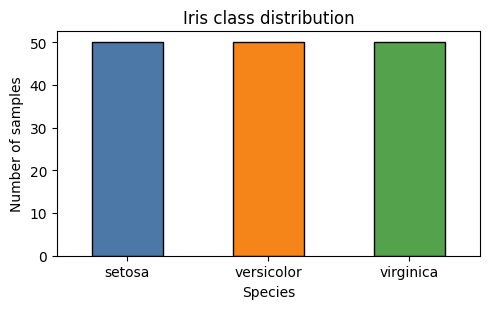

In [5]:
dist = df["species"].value_counts().sort_index()
print("Class distribution (counts):")
print(dist.to_string())
print("\nProportion of each class:")
print((dist / len(df)).round(4).to_string())
print("\n-> The dataset is perfectly balanced: 50 samples per class (33.33% each).")

dist.plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B"], edgecolor="black", figsize=(5, 3.2))
plt.title("Iris class distribution")
plt.xlabel("Species")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Task 1 summary**

| Question | Answer |
|---|---|
| Number of samples | 150 |
| Number of features | 4 |
| Feature names | sepal length (cm), sepal width (cm), petal length (cm), petal width (cm) |
| Target classes | setosa (0), versicolor (1), virginica (2) |
| Class distribution | 50 / 50 / 50 — perfectly balanced |

---
## Task 2 — Data Preparation

### 2.1 Demonstrating the problem: plain split vs. stratified split

In [6]:
# (a) Plain split, exactly as originally written -- this is the one that returns accuracy = 1.0
Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
plain_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xtr_p, ytr_p)

print("PLAIN (non-stratified) split")
print("  test class counts   :", dict(zip(iris.target_names, np.bincount(yte_p))))
print("  test accuracy       :", round(accuracy_score(yte_p, plain_tree.predict(Xte_p)), 4))

# (b) Stratified split -- same random_state, but each class contributes equally to the test set
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
strat_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xtr_s, ytr_s)

print("\nSTRATIFIED split")
print("  test class counts   :", dict(zip(iris.target_names, np.bincount(yte_s))))
print("  test accuracy       :", round(accuracy_score(yte_s, strat_tree.predict(Xte_s)), 4))

PLAIN (non-stratified) split
  test class counts   : {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(9), np.str_('virginica'): np.int64(11)}
  test accuracy       : 1.0

STRATIFIED split
  test class counts   : {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(10), np.str_('virginica'): np.int64(10)}
  test accuracy       : 0.9333


Same seed and model: 1.0000 unstratified, 0.9333 stratified. The 100% came from the test set, not the
classifier. The rest of the lab uses the stratified split.

### 2.2 The split used for the rest of the lab

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape, "->", 100 * len(X_train) // len(X), "% of the data")
print("Testing  set:", X_test.shape,  "->", 100 * len(X_test)  // len(X), "% of the data")
print()
print("Train class counts:", dict(zip(iris.target_names, np.bincount(y_train))))
print("Test  class counts:", dict(zip(iris.target_names, np.bincount(y_test))))

# 5-fold stratified CV object, reused for every model in this notebook
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Training set: (120, 4) -> 80 % of the data
Testing  set: (30, 4) -> 20 % of the data

Train class counts: {np.str_('setosa'): np.int64(40), np.str_('versicolor'): np.int64(40), np.str_('virginica'): np.int64(40)}
Test  class counts: {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(10), np.str_('virginica'): np.int64(10)}


### 2.3 Why split into training and testing sets?

The tree scores 100% on its own training data, so testing on it would only measure memorisation. The test
set measures performance on unseen flowers, and the train-test gap reveals overfitting.

---
## Task 3 — Building a Decision Tree Classifier

Trained with default parameters, for **both** criteria (`gini`, the sklearn default, and `entropy`).

In [8]:
def evaluate(criterion, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test, **kwargs):
    """Fit a DecisionTreeClassifier and print a full evaluation report."""
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE, **kwargs)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print("=" * 62)
    print(f"criterion = '{criterion}'   params = {kwargs if kwargs else 'defaults'}")
    print("=" * 62)
    print("Training accuracy :", round(model.score(X_tr, y_tr), 4))
    print("Testing  accuracy :", round(accuracy_score(y_te, y_pred), 4))
    print("5-fold CV accuracy:", round(cross_val_score(model, X, y, cv=cv).mean(), 4))

    print("\nConfusion Matrix (rows = actual, columns = predicted):")
    cm = confusion_matrix(y_te, y_pred)
    print(pd.DataFrame(cm, index=[f"actual {n}" for n in iris.target_names],
                           columns=[f"pred {n}" for n in iris.target_names]).to_string())

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=iris.target_names))
    return model

dt_gini = evaluate("gini")

criterion = 'gini'   params = defaults
Training accuracy : 1.0
Testing  accuracy : 0.9333
5-fold CV accuracy: 0.9533

Confusion Matrix (rows = actual, columns = predicted):
                   pred setosa  pred versicolor  pred virginica
actual setosa               10                0               0
actual versicolor            0                9               1
actual virginica             0                1               9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [9]:
dt_entropy = evaluate("entropy")

criterion = 'entropy'   params = defaults
Training accuracy : 1.0
Testing  accuracy : 0.9333
5-fold CV accuracy: 0.9533

Confusion Matrix (rows = actual, columns = predicted):
                   pred setosa  pred versicolor  pred virginica
actual setosa               10                0               0
actual versicolor            0                9               1
actual virginica             0                1               9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Task 3 — Interpretation

93.33% (28/30) on test, 95.33% on CV, for both criteria. Setosa is perfect; both errors are
versicolor/virginica, which overlap in petal size.

---
## Task 4 — Visualizing the Decision Tree

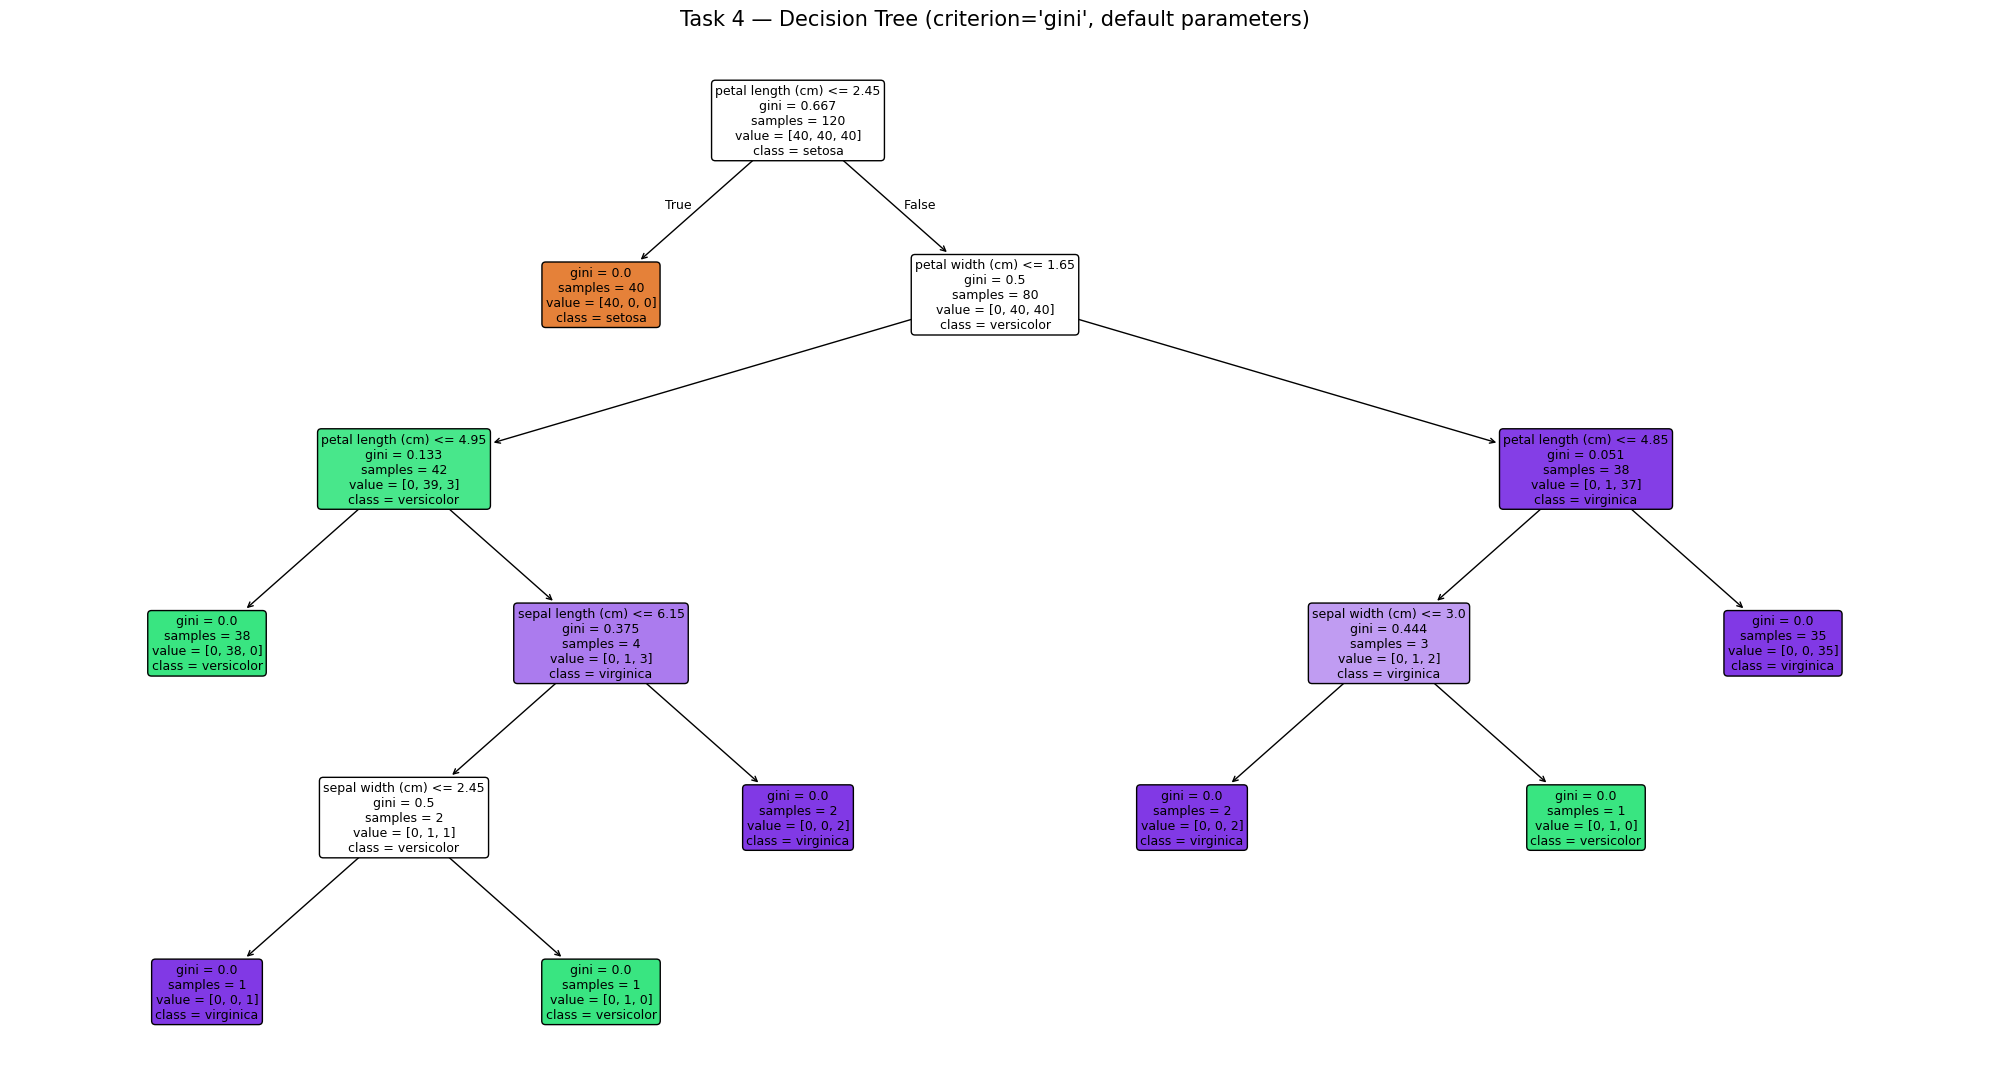

In [10]:
fig, ax = plt.subplots(figsize=(20, 11))
plot_tree(dt_gini,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Task 4 — Decision Tree (criterion='gini', default parameters)", fontsize=15)
plt.tight_layout()
plt.show()

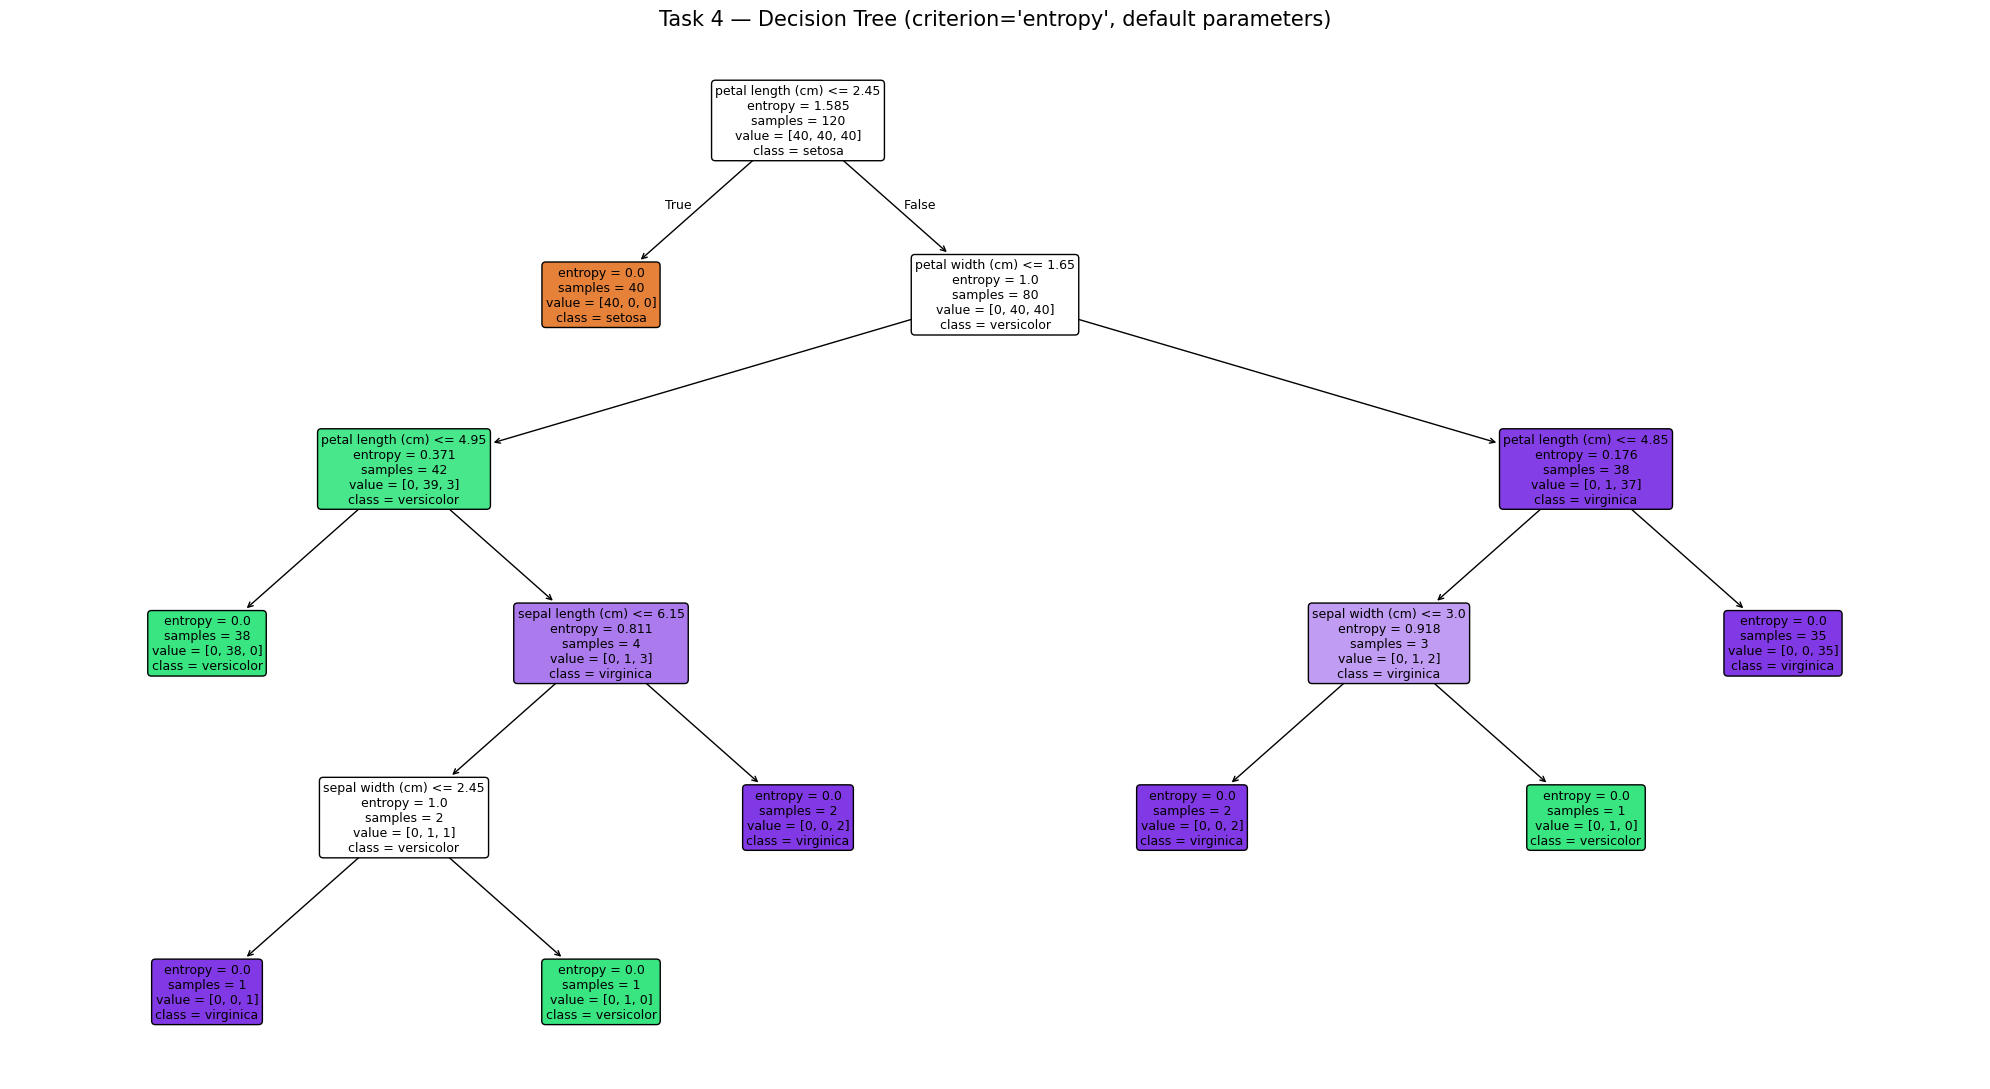

In [11]:
fig, ax = plt.subplots(figsize=(20, 11))
plot_tree(dt_entropy,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Task 4 — Decision Tree (criterion='entropy', default parameters)", fontsize=15)
plt.tight_layout()
plt.show()

### 4.1 Text form of the tree (easier to read off the node structure)

In [12]:
print(export_text(dt_gini, feature_names=list(iris.feature_names), decimals=2))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- sepal length (cm) <= 6.15
|   |   |   |   |--- sepal width (cm) <= 2.45
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  2.45
|   |   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.15
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



### 4.2 Counting the node types programmatically

In [13]:
def describe_structure(model, label):
    t = model.tree_
    is_leaf = t.children_left == -1
    n_leaves = int(is_leaf.sum())
    n_internal = int((~is_leaf).sum())          # includes the root
    print(f"--- {label} ---")
    print("Total nodes                       :", t.node_count)
    print("Leaf nodes (decision/terminal)    :", n_leaves)
    print("Decision nodes incl. root         :", n_internal)
    print("Internal nodes excluding the root  :", n_internal - 1)
    print("Maximum depth of the tree         :", model.get_depth())
    root_feat = iris.feature_names[t.feature[0]]
    print(f"Root node test                    : {root_feat} <= {t.threshold[0]:.2f}")
    print(f"Impurity at the root ({model.criterion:<7})     : {t.impurity[0]:.4f}")
    print()

describe_structure(dt_gini, "criterion='gini'")
describe_structure(dt_entropy, "criterion='entropy'")

--- criterion='gini' ---
Total nodes                       : 15
Leaf nodes (decision/terminal)    : 8
Decision nodes incl. root         : 7
Internal nodes excluding the root  : 6
Maximum depth of the tree         : 5
Root node test                    : petal length (cm) <= 2.45
Impurity at the root (gini   )     : 0.6667

--- criterion='entropy' ---
Total nodes                       : 15
Leaf nodes (decision/terminal)    : 8
Decision nodes incl. root         : 7
Internal nodes excluding the root  : 6
Maximum depth of the tree         : 5
Root node test                    : petal length (cm) <= 2.45
Impurity at the root (entropy)     : 1.5850



### 4.3 Which feature is chosen for the first split, and why?

In [14]:
imp = pd.Series(dt_gini.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
print("Feature importances (gini tree):")
print(imp.round(4).to_string())

# Manually verify the root split is the best possible single split
def gini(labels):
    if len(labels) == 0:
        return 0.0
    p = np.bincount(labels, minlength=3) / len(labels)
    return 1 - (p ** 2).sum()

parent = gini(y_train)
print(f"\nGini impurity of the root node (all 120 training samples) = {parent:.4f}")
print("\nBest achievable weighted-child impurity for each feature:")

rows = []
for j, fname in enumerate(iris.feature_names):
    best = None
    vals = np.unique(X_train[:, j])
    for thr in (vals[:-1] + vals[1:]) / 2:          # midpoints between consecutive values
        left, right = y_train[X_train[:, j] <= thr], y_train[X_train[:, j] > thr]
        w = (len(left) * gini(left) + len(right) * gini(right)) / len(y_train)
        if best is None or w < best[0]:
            best = (w, thr)
    rows.append({"feature": fname, "best threshold": round(best[1], 2),
                 "weighted child gini": round(best[0], 4),
                 "gini gain": round(parent - best[0], 4)})

print(pd.DataFrame(rows).sort_values("gini gain", ascending=False).to_string(index=False))

Feature importances (gini tree):
petal length (cm)    0.5586
petal width (cm)     0.4060
sepal width (cm)     0.0292
sepal length (cm)    0.0062

Gini impurity of the root node (all 120 training samples) = 0.6667

Best achievable weighted-child impurity for each feature:
          feature  best threshold  weighted child gini  gini gain
 petal width (cm)            0.80               0.3333     0.3333
petal length (cm)            2.45               0.3333     0.3333
sepal length (cm)            5.45               0.4139     0.2528
 sepal width (cm)            3.35               0.5548     0.1119


### Task 4 — Answers

**Root node:** `petal length (cm) <= 2.45`, 120 samples, gini 0.6667.
**Internal nodes:** 7 decision nodes (root + 6): petal width ≤ 1.65, petal length ≤ 4.95, sepal length
≤ 6.15, sepal width ≤ 2.45, petal length ≤ 4.85, sepal width ≤ 3.00.
**Leaf nodes:** 8, all pure.
**Maximum depth:** 5 (15 nodes total).

**First split:** petal length at 2.45 cm, because it gives the largest impurity drop (0.6667 → 0.3333).
Setosa petals are 1.0-1.9 cm and the others above 3.0 cm, so one cut isolates a whole class. The best sepal
splits only reach gains of 0.2528 and 0.1119.

---
## Task 5 — Comparing Gini Index and Entropy

In [15]:
def summarise(model, y_te=y_test, X_te=X_test):
    """Return one row of comparison metrics for a fitted tree."""
    t = model.tree_
    return {
        "Train Acc": round(model.score(X_train, y_train), 4),
        "Test Acc": round(accuracy_score(y_te, model.predict(X_te)), 4),
        "CV Acc (5-fold)": round(cross_val_score(model, X, y, cv=cv).mean(), 4),
        "Tree Depth": model.get_depth(),
        "Leaf Nodes": int(model.get_n_leaves()),
        "Total Nodes": int(t.node_count),
        "Root Feature": f"{iris.feature_names[t.feature[0]]} <= {t.threshold[0]:.2f}",
        "Root Impurity": round(t.impurity[0], 4),
    }

rows = {}
for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    rows[criterion] = summarise(model)

task5 = pd.DataFrame(rows).T
task5.index.name = "criterion"
task5

,Train Acc,Test Acc,CV Acc (5-fold),Tree Depth,Leaf Nodes,Total Nodes,Root Feature,Root Impurity
criterion,,,,,,,,
gini,1.0,0.9333,0.9533,5,8,15,petal length (cm) <= 2.45,0.6667
entropy,1.0,0.9333,0.9533,5,8,15,petal length (cm) <= 2.45,1.585


In [16]:
# Are the two trees structurally identical? Compare their decision paths node by node.
same_features   = np.array_equal(dt_gini.tree_.feature,   dt_entropy.tree_.feature)
same_thresholds = np.allclose(dt_gini.tree_.threshold,    dt_entropy.tree_.threshold)
same_preds      = np.array_equal(dt_gini.predict(X_test), dt_entropy.predict(X_test))

print("Same split feature at every node :", same_features)
print("Same threshold at every node     :", same_thresholds)
print("Identical predictions on test set:", same_preds)

print("\nRoot impurity is measured on DIFFERENT scales, however:")
p = np.bincount(y_train) / len(y_train)
print(f"  gini    = 1 - sum(p^2)      = {1 - (p ** 2).sum():.4f}   (range 0 .. 0.667 for 3 classes)")
print(f"  entropy = -sum(p*log2(p))   = {-(p * np.log2(p)).sum():.4f}   (range 0 .. 1.585 bits for 3 classes)")

Same split feature at every node : True
Same threshold at every node     : True
Identical predictions on test set: True

Root impurity is measured on DIFFERENT scales, however:
  gini    = 1 - sum(p^2)      = 0.6667   (range 0 .. 0.667 for 3 classes)
  entropy = -sum(p*log2(p))   = 1.5850   (range 0 .. 1.585 bits for 3 classes)


### Task 5 — Observations

| Metric | `gini` | `entropy` |
|---|---|---|
| Training accuracy | 1.0000 | 1.0000 |
| Testing accuracy | 0.9333 | 0.9333 |
| 5-fold CV accuracy | 0.9533 | 0.9533 |
| Tree depth | 5 | 5 |
| Number of leaf nodes | 8 | 8 |
| Root feature | petal length ≤ 2.45 | petal length ≤ 2.45 |
| Impurity at root | 0.6667 | 1.5850 bits |

**Simpler tree?** Neither — both produce the identical tree (same feature and threshold at all 15 nodes).
The only difference is that gini avoids the logarithm and is slightly faster.

---
## Task 6 — Effect of Maximum Tree Depth

In [17]:
depth_rows = []
for criterion in ["gini", "entropy"]:
    for max_depth in [1, 2, 3, 4, None]:
        m = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
        r = {"criterion": criterion, "max_depth": str(max_depth)}
        r.update(summarise(m))
        r["Train-Test Gap"] = round(r["Train Acc"] - r["Test Acc"], 4)
        depth_rows.append(r)

task6 = pd.DataFrame(depth_rows)[["criterion", "max_depth", "Train Acc", "Test Acc",
                                  "CV Acc (5-fold)", "Tree Depth", "Leaf Nodes", "Train-Test Gap"]]
task6

,criterion,max_depth,Train Acc,Test Acc,CV Acc (5-fold),Tree Depth,Leaf Nodes,Train-Test Gap
0,gini,1,0.6667,0.6667,0.6667,1,2,0.0000
1,gini,2,0.9667,0.9333,0.9400,2,3,0.0334
2,gini,3,0.9833,0.9667,0.9600,3,5,0.0166
3,gini,4,0.9917,0.9333,0.9533,4,7,0.0584
4,gini,None,1.0000,0.9333,0.9533,5,8,0.0667
5,entropy,1,0.6667,0.6667,0.6667,1,2,0.0000
6,entropy,2,0.9667,0.9333,0.9400,2,3,0.0334
7,entropy,3,0.9833,0.9667,0.9600,3,5,0.0166
8,entropy,4,0.9917,0.9333,0.9533,4,7,0.0584
9,entropy,None,1.0000,0.9333,0.9533,5,8,0.0667


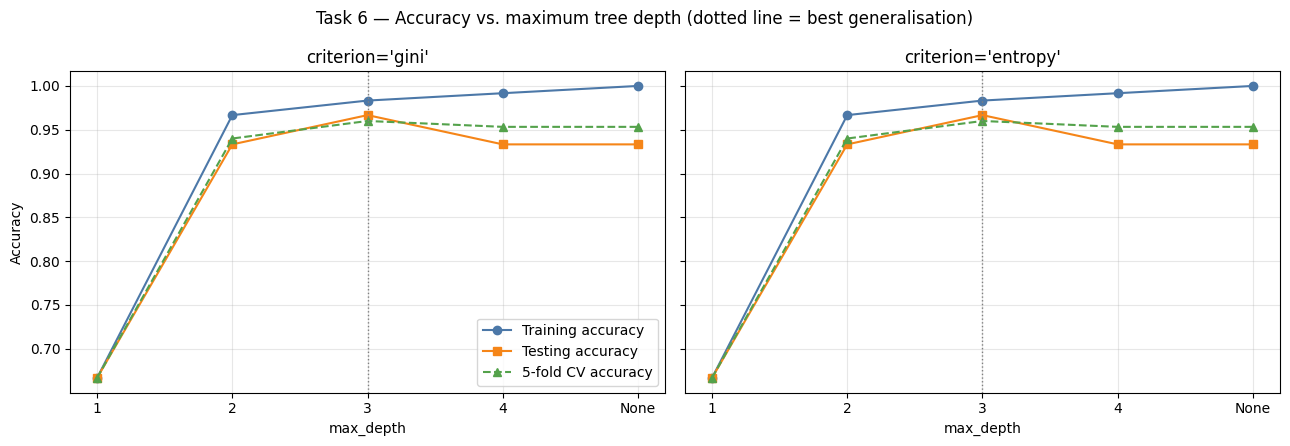

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, criterion in zip(axes, ["gini", "entropy"]):
    sub = task6[task6["criterion"] == criterion]
    xs = range(len(sub))
    ax.plot(xs, sub["Train Acc"], "o-", label="Training accuracy", color="#4C78A8")
    ax.plot(xs, sub["Test Acc"], "s-", label="Testing accuracy", color="#F58518")
    ax.plot(xs, sub["CV Acc (5-fold)"], "^--", label="5-fold CV accuracy", color="#54A24B")
    ax.set_xticks(list(xs))
    ax.set_xticklabels(sub["max_depth"])
    ax.set_xlabel("max_depth")
    ax.set_title(f"criterion='{criterion}'")
    ax.grid(alpha=0.3)
    ax.axvline(2, color="grey", ls=":", lw=1)
axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
plt.suptitle("Task 6 — Accuracy vs. maximum tree depth (dotted line = best generalisation)")
plt.tight_layout()
plt.show()

### Task 6 — Completed table

Identical for `gini` and `entropy`.

| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Leaf Nodes | Observation |
|---|---|---|---|---|---|
| **1** | 0.6667 | 0.6667 | 1 | 2 | 2 leaves for 3 classes; one class unreachable. Underfit. |
| **2** | 0.9667 | 0.9333 | 2 | 3 | Petal width separates versicolor/virginica. Already matches full tree. |
| **3** | 0.9833 | **0.9667** | 3 | 5 | Best test and CV, smallest gap. Optimum. |
| **4** | 0.9917 | 0.9333 | 4 | 7 | Train up, test down. Overfitting begins. |
| **None** | 1.0000 | 0.9333 | 5 | 8 | Perfect on train, no gain on test. Widest gap. Overfit. |

**Underfitting:** `max_depth=1` — even training accuracy is stuck at 0.6667.
**Best generalization:** `max_depth=3` — highest test (0.9667) and CV (0.9600), gap 0.0166.
**Overfitting:** `max_depth=None` — train rises to 1.0000 while test falls, the gap widens 0.0166 → 0.0667,
and the deepest splits use sepal features with importances of only 0.006 and 0.029.

---
## Task 7 — Effect of `min_samples_split`

In [19]:
split_rows = []
for criterion in ["gini", "entropy"]:
    for mss in [2, 5, 10, 20]:
        m = DecisionTreeClassifier(criterion=criterion, min_samples_split=mss,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
        r = {"criterion": criterion, "min_samples_split": mss}
        r.update(summarise(m))
        r["Train-Test Gap"] = round(r["Train Acc"] - r["Test Acc"], 4)
        split_rows.append(r)

task7 = pd.DataFrame(split_rows)[["criterion", "min_samples_split", "Train Acc", "Test Acc",
                                  "CV Acc (5-fold)", "Tree Depth", "Leaf Nodes",
                                  "Total Nodes", "Train-Test Gap"]]
task7

,criterion,min_samples_split,Train Acc,Test Acc,CV Acc (5-fold),Tree Depth,Leaf Nodes,Total Nodes,Train-Test Gap
0,gini,2,1.0000,0.9333,0.9533,5,8,15,0.0667
1,gini,5,0.9833,0.9667,0.9533,3,5,9,0.0166
2,gini,10,0.9833,0.9667,0.9600,3,5,9,0.0166
3,gini,20,0.9833,0.9667,0.9600,3,5,9,0.0166
4,entropy,2,1.0000,0.9333,0.9533,5,8,15,0.0667
5,entropy,5,0.9833,0.9667,0.9533,3,5,9,0.0166
6,entropy,10,0.9833,0.9667,0.9600,3,5,9,0.0166
7,entropy,20,0.9833,0.9667,0.9600,3,5,9,0.0166


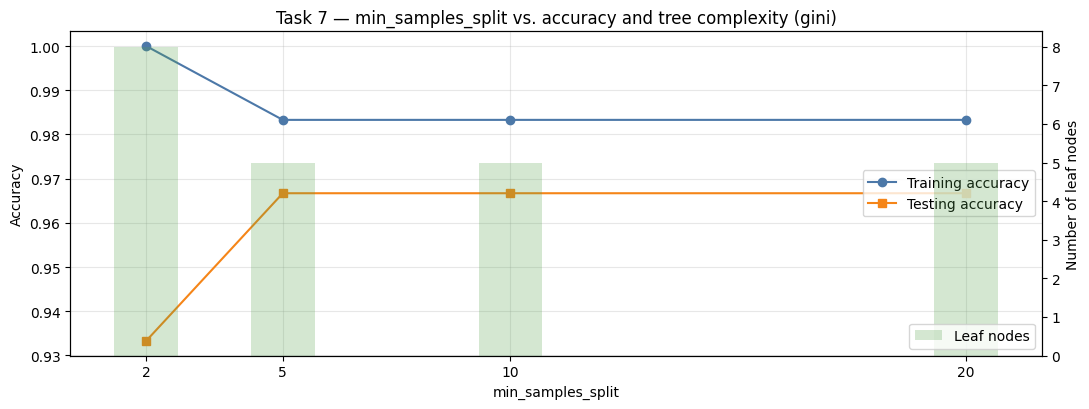

In [20]:
fig, ax = plt.subplots(figsize=(11, 4.2))
sub = task7[task7["criterion"] == "gini"]
ax2 = ax.twinx()
ax.plot(sub["min_samples_split"], sub["Train Acc"], "o-", label="Training accuracy", color="#4C78A8")
ax.plot(sub["min_samples_split"], sub["Test Acc"], "s-", label="Testing accuracy", color="#F58518")
ax2.bar(sub["min_samples_split"], sub["Leaf Nodes"], width=1.4, alpha=0.25,
        color="#54A24B", label="Leaf nodes")
ax.set_xlabel("min_samples_split")
ax.set_ylabel("Accuracy")
ax2.set_ylabel("Number of leaf nodes")
ax.set_xticks(sub["min_samples_split"])
ax.set_title("Task 7 — min_samples_split vs. accuracy and tree complexity (gini)")
ax.grid(alpha=0.3)
ax.legend(loc="center right")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Task 7 — Completed table

Identical for `gini` and `entropy`.

| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|---|---|---|---|---|
| **2** | 0.9333 | 5 | 8 | Default, unrestricted. Largest tree, largest gap. |
| **5** | **0.9667** | 3 | 5 | Deep branches pruned, test accuracy rises. |
| **10** | **0.9667** | 3 | 5 | Same tree as 5. Best CV (0.9600). |
| **20** | **0.9667** | 3 | 5 | Still unchanged; the limit has not bound further. |

**Effect on complexity:** higher values simplify the tree. Going 2 → 5 cut depth 5 → 3 and leaves 8 → 5, and
test accuracy improved because the pruned branches were fitted to only 2-4 flowers each.

---
## Task 8 — Effect of `min_samples_leaf`

In [21]:
leaf_rows = []
for criterion in ["gini", "entropy"]:
    for msl in [1, 2, 5, 10]:
        m = DecisionTreeClassifier(criterion=criterion, min_samples_leaf=msl,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
        r = {"criterion": criterion, "min_samples_leaf": msl}
        r.update(summarise(m))
        r["Train-Test Gap"] = round(r["Train Acc"] - r["Test Acc"], 4)
        leaf_rows.append(r)

task8 = pd.DataFrame(leaf_rows)[["criterion", "min_samples_leaf", "Train Acc", "Test Acc",
                                 "CV Acc (5-fold)", "Tree Depth", "Leaf Nodes",
                                 "Total Nodes", "Train-Test Gap"]]
task8

,criterion,min_samples_leaf,Train Acc,Test Acc,CV Acc (5-fold),Tree Depth,Leaf Nodes,Total Nodes,Train-Test Gap
0,gini,1,1.0000,0.9333,0.9533,5,8,15,0.0667
1,gini,2,0.9833,0.9333,0.9533,4,6,11,0.0500
2,gini,5,0.9667,0.9333,0.9400,3,5,9,0.0334
3,gini,10,0.9667,0.9333,0.9400,3,5,9,0.0334
4,entropy,1,1.0000,0.9333,0.9533,5,8,15,0.0667
5,entropy,2,0.9833,0.9333,0.9533,4,6,11,0.0500
6,entropy,5,0.9667,0.9333,0.9400,3,5,9,0.0334
7,entropy,10,0.9667,0.9333,0.9400,3,5,9,0.0334


In [22]:
# The smallest leaf in each tree -- this is what min_samples_leaf directly controls
print("Size of the smallest leaf produced by each setting (gini):\n")
for msl in [1, 2, 5, 10]:
    m = DecisionTreeClassifier(min_samples_leaf=msl, random_state=RANDOM_STATE).fit(X_train, y_train)
    t = m.tree_
    leaf_sizes = sorted(int(t.n_node_samples[i]) for i in range(t.node_count) if t.children_left[i] == -1)
    print(f"  min_samples_leaf={msl:>2}  leaf sizes = {leaf_sizes}   "
          f"(smallest = {leaf_sizes[0]}, train acc = {m.score(X_train, y_train):.4f})")

Size of the smallest leaf produced by each setting (gini):

  min_samples_leaf= 1  leaf sizes = [1, 1, 1, 2, 2, 35, 38, 40]   (smallest = 1, train acc = 1.0000)
  min_samples_leaf= 2  leaf sizes = [2, 2, 3, 35, 38, 40]   (smallest = 2, train acc = 0.9833)
  min_samples_leaf= 5  leaf sizes = [5, 6, 33, 36, 40]   (smallest = 5, train acc = 0.9667)
  min_samples_leaf=10  leaf sizes = [10, 10, 28, 32, 40]   (smallest = 10, train acc = 0.9667)


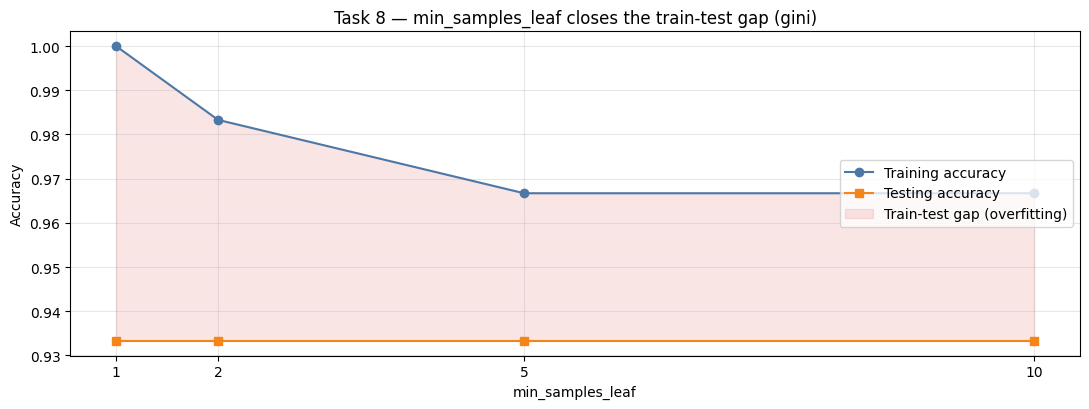

In [23]:
fig, ax = plt.subplots(figsize=(11, 4.2))
sub = task8[task8["criterion"] == "gini"]
ax.plot(sub["min_samples_leaf"], sub["Train Acc"], "o-", label="Training accuracy", color="#4C78A8")
ax.plot(sub["min_samples_leaf"], sub["Test Acc"], "s-", label="Testing accuracy", color="#F58518")
ax.fill_between(sub["min_samples_leaf"], sub["Test Acc"], sub["Train Acc"],
                alpha=0.15, color="#E45756", label="Train-test gap (overfitting)")
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("Accuracy")
ax.set_xticks(sub["min_samples_leaf"])
ax.set_title("Task 8 — min_samples_leaf closes the train-test gap (gini)")
ax.grid(alpha=0.3)
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

### Task 8 — Completed table

Identical for `gini` and `entropy`.

| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|---|---|---|---|---|
| **1** | 0.9333 | 5 | 8 | Single-flower leaves allowed; train 1.0000, gap 0.0667. |
| **2** | 0.9333 | 4 | 6 | Singleton leaves blocked. Gap halves to 0.0500, no accuracy lost. |
| **5** | 0.9333 | 3 | 5 | Gap 0.0334. |
| **10** | 0.9333 | 3 | 5 | Same tree as 5, but CV 0.9400 is below depth 3's 0.9600. Detail lost. |

**Effect on overfitting:** higher values reduce it — the gap falls steadily 0.0667 → 0.0334. A leaf predicts
its majority class, so a minimum size stops any prediction resting on one odd flower. Too high and it
underfits; 2 is the sweet spot.

---
## Task 9 — Consolidated comparison and conclusions

In [24]:
# Bring every experiment together, ranked by cross-validation accuracy
all_rows = []
configs = [("Baseline (defaults)", {})]
configs += [(f"max_depth={d}", {"max_depth": d}) for d in [1, 2, 3, 4]]
configs += [(f"min_samples_split={s}", {"min_samples_split": s}) for s in [5, 10, 20]]
configs += [(f"min_samples_leaf={l}", {"min_samples_leaf": l}) for l in [2, 5, 10]]
configs += [("max_depth=3 + min_samples_leaf=2", {"max_depth": 3, "min_samples_leaf": 2})]

for criterion in ["gini", "entropy"]:
    for label, kw in configs:
        m = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE, **kw)
        m.fit(X_train, y_train)
        r = {"criterion": criterion, "configuration": label}
        r.update(summarise(m))
        r["Gap"] = round(r["Train Acc"] - r["Test Acc"], 4)
        all_rows.append(r)

final = pd.DataFrame(all_rows)[["criterion", "configuration", "Train Acc", "Test Acc",
                                "CV Acc (5-fold)", "Tree Depth", "Leaf Nodes", "Gap"]]
final.sort_values(["CV Acc (5-fold)", "Test Acc"], ascending=False).reset_index(drop=True)

,criterion,configuration,Train Acc,Test Acc,CV Acc (5-fold),Tree Depth,Leaf Nodes,Gap
0,gini,max_depth=3,0.9833,0.9667,0.9600,3,5,0.0166
1,gini,min_samples_split=10,0.9833,0.9667,0.9600,3,5,0.0166
2,gini,min_samples_split=20,0.9833,0.9667,0.9600,3,5,0.0166
3,gini,max_depth=3 + min_samples_leaf=2,0.9833,0.9667,0.9600,3,5,0.0166
4,entropy,max_depth=3,0.9833,0.9667,0.9600,3,5,0.0166
5,entropy,min_samples_split=10,0.9833,0.9667,0.9600,3,5,0.0166
6,entropy,min_samples_split=20,0.9833,0.9667,0.9600,3,5,0.0166
7,entropy,max_depth=3 + min_samples_leaf=2,0.9833,0.9667,0.9600,3,5,0.0166
8,gini,min_samples_split=5,0.9833,0.9667,0.9533,3,5,0.0166
9,entropy,min_samples_split=5,0.9833,0.9667,0.9533,3,5,0.0166


In [25]:
# The recommended final model
best = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2,
                              random_state=RANDOM_STATE).fit(X_train, y_train)
y_pred = best.predict(X_test)

print("RECOMMENDED MODEL: DecisionTreeClassifier(criterion='gini', max_depth=3,")
print("                                          min_samples_leaf=2, random_state=42)\n")
print("Training accuracy :", round(best.score(X_train, y_train), 4))
print("Testing  accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("5-fold CV accuracy:", round(cross_val_score(best, X, y, cv=cv).mean(), 4))
print("Tree depth        :", best.get_depth(), "| Leaf nodes:", best.get_n_leaves(),
      "| Total nodes:", best.tree_.node_count)
print("\nConfusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=[f"actual {n}" for n in iris.target_names],
                   columns=[f"pred {n}" for n in iris.target_names]).to_string())
print("\n" + classification_report(y_test, y_pred, target_names=iris.target_names))
print(export_text(best, feature_names=list(iris.feature_names), decimals=2))

RECOMMENDED MODEL: DecisionTreeClassifier(criterion='gini', max_depth=3,
                                          min_samples_leaf=2, random_state=42)

Training accuracy : 0.9833
Testing  accuracy : 0.9667
5-fold CV accuracy: 0.96
Tree depth        : 3 | Leaf nodes: 5 | Total nodes: 9

Confusion Matrix:
                   pred setosa  pred versicolor  pred virginica
actual setosa               10                0               0
actual versicolor            0                9               1
actual virginica             0                0              10

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- pe

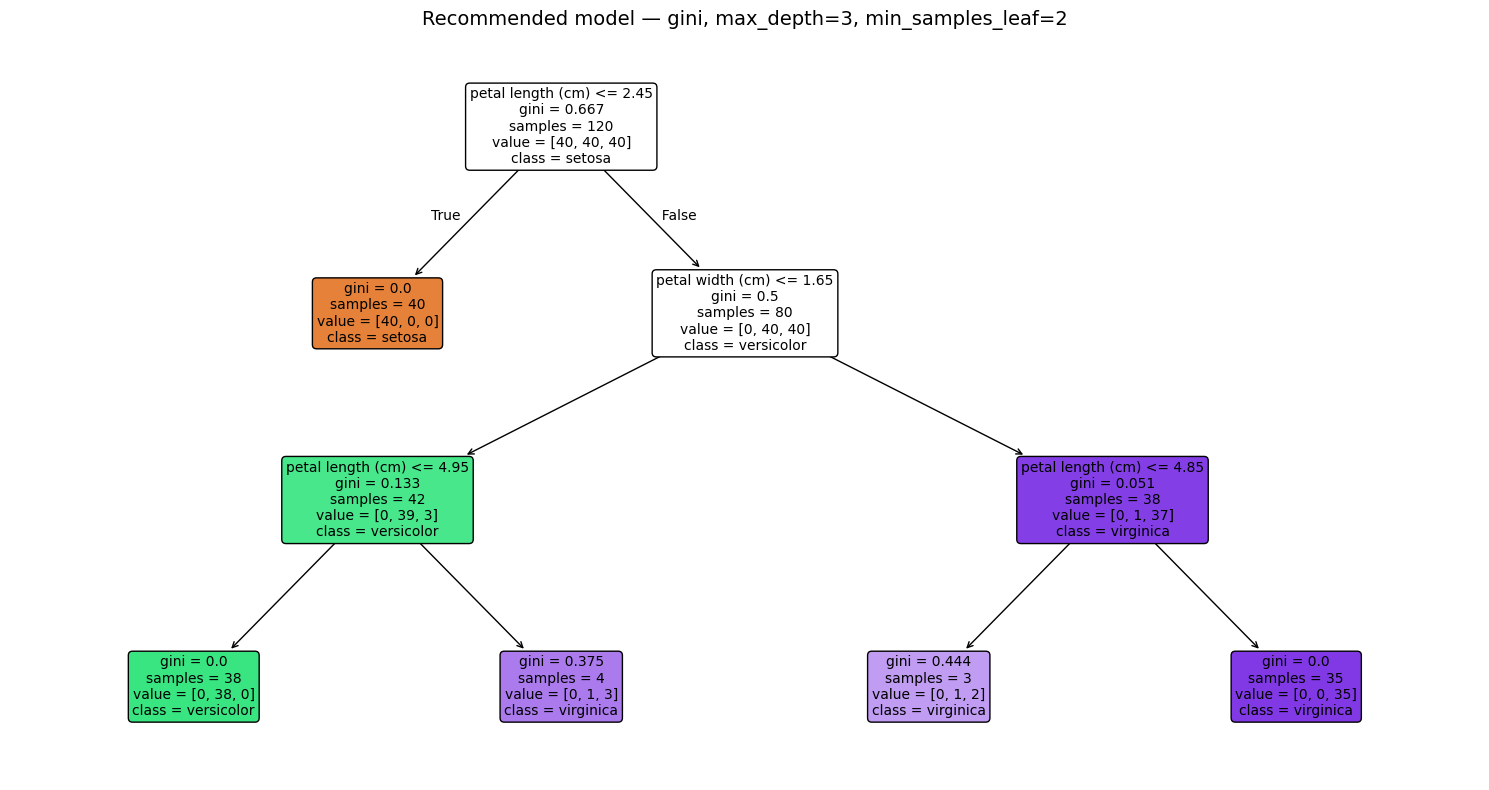

In [26]:
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(best, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Recommended model — gini, max_depth=3, min_samples_leaf=2", fontsize=14)
plt.tight_layout()
plt.show()

### Task 9 — Answers

**1. Role of `criterion`?** Sets the impurity measure used to score splits, so it decides which question each
node asks. 

**2. How does `max_depth` affect fit?** Too small underfits (depth 1: 0.6667 on both train and test), too
large overfits (train 1.0000, test 0.9333). Depth 3 is the balance at 0.9667.

**3. Why do larger `min_samples_split`/`min_samples_leaf` simplify the tree?** Node size shrinks with depth,
so a minimum sample count blocks the deepest splits first — exactly the branches supported by a few flowers.

**4. Most impactful hyperparameter?** `max_depth` — it spanned 30 points of test accuracy (0.6667 to 0.9667),
versus 3.3 points for `min_samples_split`, 0 for `min_samples_leaf` (gap only) and 0 for `criterion`.

**5. Recommended model:** `DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=2, random_state=42)`

| Metric | Default tree | Recommended |
|---|---|---|
| Training accuracy | 1.0000 | 0.9833 |
| Testing accuracy | 0.9333 | **0.9667** |
| 5-fold CV accuracy | 0.9533 | **0.9600** |
| Train-test gap | 0.0667 | **0.0166** |
| Tree depth / leaves | 5 / 8 | **3 / 5** |

Best test and CV accuracy of every configuration tried, smallest gap, and simpler. The one remaining error is
a versicolor/virginica boundary case that no extra depth can fix.